In [33]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error


In [2]:
rel_stock=pd.read_csv(filepath_or_buffer="RILO - Copy.csv")
rel_stock

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
0,RELIANCE,EQ,1-Jan-16,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135,1.257353e+09,30701,529539,42.77
1,RELIANCE,EQ,4-Jan-16,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571,6.889070e+09,66235,4974602,72.13
2,RELIANCE,EQ,5-Jan-16,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459,3.428125e+09,59935,1987804,58.18
3,RELIANCE,EQ,6-Jan-16,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855,6.289073e+09,160947,2912662,47.62
4,RELIANCE,EQ,7-Jan-16,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219,4.587700e+09,105075,2474491,54.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319,RELIANCE,EQ,30-Apr-21,2024.05,2008.50,2036.0,1987.55,1995.9,1994.50,2010.20,9150974,1.839532e+10,288687,3902504,42.65
1320,RELIANCE,EQ,3-May-21,1994.50,1966.00,1979.0,1943.10,1956.0,1959.05,1958.46,10909942,2.136664e+10,343806,3800598,34.84
1321,RELIANCE,EQ,4-May-21,1959.05,1950.00,1967.8,1911.00,1918.0,1916.60,1935.83,10083693,1.952033e+10,325798,4435071,43.98
1322,RELIANCE,EQ,5-May-21,1916.60,1923.35,1938.5,1908.05,1921.5,1920.10,1923.26,5719649,1.100036e+10,190990,1762417,30.81


#### DATA UNDERSTANDING

In [3]:
rel_stock.isna().sum()

Symbol                    0
Series                    0
Date                      0
Prev Close                0
Open Price                0
High Price                0
Low Price                 0
Last Price                0
Close Price               0
Average Price             0
Total Traded Quantity     0
Turnover                  0
No. of Trades             0
Deliverable Qty           0
% Dly Qt to Traded Qty    0
dtype: int64

In [4]:
rel_stock.dtypes

Symbol                     object
Series                     object
Date                       object
Prev Close                float64
Open Price                float64
High Price                float64
Low Price                 float64
Last Price                float64
Close Price               float64
Average Price             float64
Total Traded Quantity       int64
Turnover                  float64
No. of Trades               int64
Deliverable Qty             int64
% Dly Qt to Traded Qty    float64
dtype: object

In [5]:
rel_stock.describe()

,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
count,1324.000000,1324.000000,1324.000000,1324.000000,1324.000000,1324.000000,1324.000000,1.324000e+03,1.324000e+03,1.324000e+03,1.324000e+03,1324.000000
mean,1311.043807,1313.436254,1328.644864,1297.260876,1312.213935,1312.119864,1313.226805,8.873225e+06,1.283806e+10,1.959810e+05,3.583648e+06,45.719252
std,377.738596,379.462103,384.037322,372.970908,378.085826,377.840674,378.449456,7.489692e+06,1.380620e+10,1.572366e+05,2.424792e+06,13.352733
min,780.900000,791.750000,793.400000,779.100000,781.200000,780.900000,785.510000,3.621700e+05,3.812024e+08,1.000000e+00,1.252240e+05,11.480000
25%,1012.837500,1014.000000,1023.725000,1003.425000,1012.862500,1013.037500,1013.945000,4.159562e+06,4.447683e+09,9.206475e+04,2.038083e+06,36.517500
50%,1230.075000,1231.750000,1244.300000,1214.175000,1230.900000,1231.275000,1228.885000,6.862827e+06,8.394594e+09,1.525885e+05,2.946626e+06,45.760000
75%,1486.362500,1481.000000,1506.837500,1464.287500,1487.625000,1488.487500,1486.270000,1.081276e+07,1.602505e+10,2.373675e+05,4.393399e+06,55.210000
max,2324.550000,2325.000000,2369.350000,2310.550000,2324.900000,2324.550000,2339.460000,6.523089e+07,1.473430e+11,1.428490e+06,1.919505e+07,100.000000


In [6]:
rel_stock.head()

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
0,RELIANCE,EQ,1-Jan-16,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135,1.257353e+09,30701,529539,42.77
1,RELIANCE,EQ,4-Jan-16,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571,6.889070e+09,66235,4974602,72.13
2,RELIANCE,EQ,5-Jan-16,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459,3.428125e+09,59935,1987804,58.18
3,RELIANCE,EQ,6-Jan-16,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855,6.289073e+09,160947,2912662,47.62
4,RELIANCE,EQ,7-Jan-16,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219,4.587700e+09,105075,2474491,54.84


#### DATA PREPARATION

In [7]:
rel_stock.drop(labels=["Symbol","Series","Last Price","Average Price","Turnover","No. of Trades","Deliverable Qty","% Dly Qt to Traded Qty","Prev Close"],axis=1,inplace=True)

In [8]:
rel_stock

,Date,Open Price,High Price,Low Price,Close Price,Total Traded Quantity
0,1-Jan-16,1009.80,1018.9,1008.20,1015.35,1238135
1,4-Jan-16,1005.00,1013.8,986.70,995.30,6896571
2,5-Jan-16,1000.30,1010.0,997.00,1005.15,3416459
3,6-Jan-16,1007.60,1038.4,1000.40,1032.20,6116855
4,7-Jan-16,1021.05,1028.0,1008.05,1013.25,4512219
...,...,...,...,...,...,...
1319,30-Apr-21,2008.50,2036.0,1987.55,1994.50,9150974
1320,3-May-21,1966.00,1979.0,1943.10,1959.05,10909942
1321,4-May-21,1950.00,1967.8,1911.00,1916.60,10083693
1322,5-May-21,1923.35,1938.5,1908.05,1920.10,5719649


In [9]:
rel_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   1324 non-null   object 
 1   Open Price             1324 non-null   float64
 2   High Price             1324 non-null   float64
 3   Low Price              1324 non-null   float64
 4   Close Price            1324 non-null   float64
 5   Total Traded Quantity  1324 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 62.2+ KB


In [10]:
rel_stock["Date"]=pd.to_datetime(arg=rel_stock["Date"])
rel_stock["Date"]

0      2016-01-01
1      2016-01-04
2      2016-01-05
3      2016-01-06
4      2016-01-07
          ...    
1319   2021-04-30
1320   2021-05-03
1321   2021-05-04
1322   2021-05-05
1323   2021-05-06
Name: Date, Length: 1324, dtype: datetime64[ns]

In [11]:
rel_stock.dtypes

Date                     datetime64[ns]
Open Price                      float64
High Price                      float64
Low Price                       float64
Close Price                     float64
Total Traded Quantity             int64
dtype: object

In [12]:
rel_stock.set_index("Date",inplace=True)

#### PLOT THE CLOSING PRICE

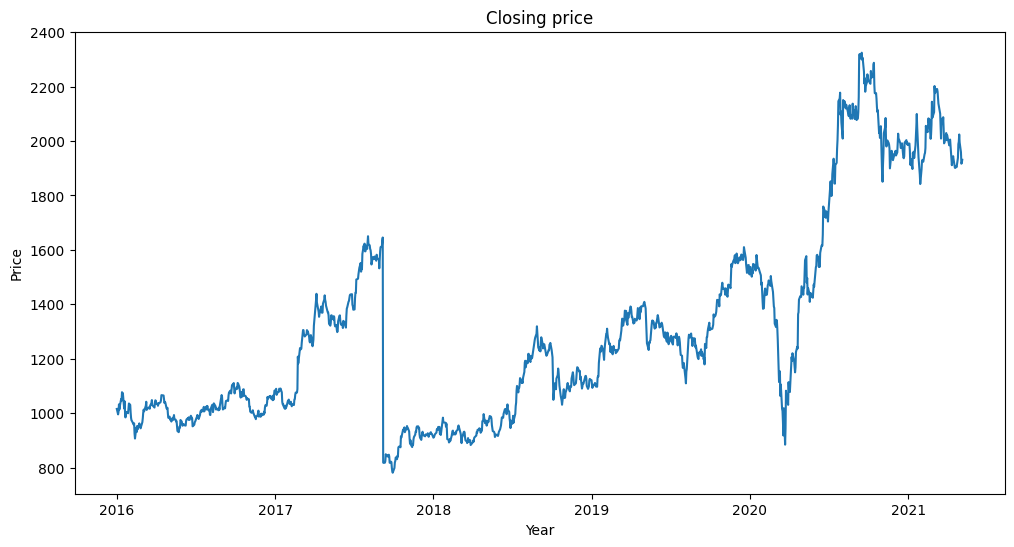

In [13]:
plt.figure(figsize=(12,6))
plt.plot(rel_stock["Close Price"])
plt.title("Closing price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

##### NOTE:
1.***STATIONARITY***:A stationary time series is one whose statistical properties remains stable over time.(***without a clear upward or downward trend***.)-------------------------
2.***NON-STATIONARITY***:The prices keep increasing over time.(***This series has a trend , so it is NON-S***) 

#### PERFORM THE ADF TEST

In [14]:
from statsmodels.tsa.stattools import adfuller 

In [15]:
result=adfuller(rel_stock["Close Price"])
print("ADF Statistic:",result[0])
print("p_value:",result[1])

ADF Statistic: -1.3517501576682631
p_value: 0.6051768942409842


##### NOTE:
1. since ***0.60517>-1.3517***, this data is non-stationary.

In [16]:
rel_stock["Close Price_diff"]=rel_stock["Close Price"].diff()
rel_stock

,Open Price,High Price,Low Price,Close Price,Total Traded Quantity,Close Price_diff
Date,,,,,,
2016-01-01,1009.80,1018.9,1008.20,1015.35,1238135,NaN
2016-01-04,1005.00,1013.8,986.70,995.30,6896571,-20.05
2016-01-05,1000.30,1010.0,997.00,1005.15,3416459,9.85
2016-01-06,1007.60,1038.4,1000.40,1032.20,6116855,27.05
2016-01-07,1021.05,1028.0,1008.05,1013.25,4512219,-18.95
...,...,...,...,...,...,...
2021-04-30,2008.50,2036.0,1987.55,1994.50,9150974,-29.55
2021-05-03,1966.00,1979.0,1943.10,1959.05,10909942,-35.45
2021-05-04,1950.00,1967.8,1911.00,1916.60,10083693,-42.45


In [17]:
rel_stock.isna().sum()

Open Price               0
High Price               0
Low Price                0
Close Price              0
Total Traded Quantity    0
Close Price_diff         1
dtype: int64

In [52]:
rel_stock.dropna()

,Open Price,High Price,Low Price,Close Price,Total Traded Quantity,Close Price_diff
Date,,,,,,
2016-01-04,1005.00,1013.8,986.70,995.30,6896571,-20.05
2016-01-05,1000.30,1010.0,997.00,1005.15,3416459,9.85
2016-01-06,1007.60,1038.4,1000.40,1032.20,6116855,27.05
2016-01-07,1021.05,1028.0,1008.05,1013.25,4512219,-18.95
2016-01-08,1020.00,1032.9,1016.70,1025.75,4871839,12.50
...,...,...,...,...,...,...
2021-04-30,2008.50,2036.0,1987.55,1994.50,9150974,-29.55
2021-05-03,1966.00,1979.0,1943.10,1959.05,10909942,-35.45
2021-05-04,1950.00,1967.8,1911.00,1916.60,10083693,-42.45


#### Difference between ACF AND PACF(ACF=AUTOCORRELATION FUNCTION,PARTIAL)

In [53]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

<Figure size 1000x500 with 0 Axes>

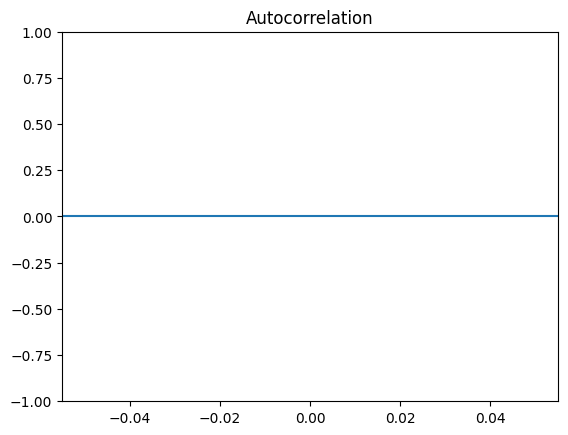

In [54]:
plt.figure(figsize=(10,5))
plot_acf(rel_stock["Close Price_diff"],lags=30)
plt.show()

<Figure size 1000x500 with 0 Axes>

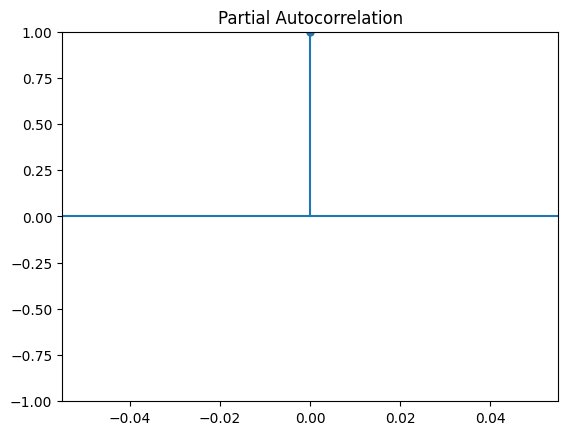

In [55]:
plt.figure(figsize=(10,5))
plot_pacf(rel_stock["Close Price_diff"],lags=30)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [62]:
model=ARIMA(rel_stock["Close Price"],order=(15,1,1))
model_fit=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Close Price   No. Observations:                 1324
Model:                ARIMA(15, 1, 1)   Log Likelihood               -6558.049
Date:                Tue, 28 Jul 2026   AIC                          13150.097
Time:                        22:19:24   BIC                          13238.287
Sample:                             0   HQIC                         13183.158
                               - 1324                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0047     30.938      0.000      1.000     -60.633      60.642
ar.L2          0.0060      0.033      0.185      0.853      -0.058       0.070
ar.L3         -0.0105      0.194     -0.054      0.9

In [63]:
forecast=model_fit.forecast(steps=5)
print(forecast)

1324    1931.012659
1325    1934.891841
1326    1934.897333
1327    1936.062233
1328    1937.202700
Name: predicted_mean, dtype: float64


##### NOTE:
***1. ARIMA model is univariate analysis so we can use [DATA,CLOSE] in the datasets.----------------------
2. HOWEVER ARIMAX model is multivariate analysis therefore we can use all features*** 

##### THE END :

============================================================================================================================================